# FDA Drug Shortage Data Explorer

### Pharmaceutical Data Analysis Using FDA Open Data

This project analyzes 100 records from the FDA Drug Shortage database to explore drug shortages by status, shortage reason, therapeutic category, company, and dosage form.

**Data Source:** U.S. Food and Drug Administration (FDA) - openFDA Drug Shortages API

### Objectives

- Explore real-world drug shortage records
- Identify common shortage reasons
- Examine affected therapeutic categories
- Analyze companies and dosage forms represented in shortage records
- Create simple visualizations to communicate pharmaceutical supply trends

## Data Source

Data were retrieved from the U.S. FDA openFDA Drug Shortages API.

The dataset contains drug shortage records with information including drug names, manufacturers, shortage status, shortage reasons, therapeutic categories, dosage forms, and posting/update dates.

**Source:** FDA openFDA Drug Shortages

## Methodology

1. Retrieved drug shortage records from the FDA openFDA API.
2. Loaded the records into a Pandas DataFrame.
3. Examined available variables and data structure.
4. Analyzed shortage status, shortage reasons, therapeutic categories, companies, and dosage forms.
5. Created visualizations to summarize the findings.
6. Created a cleaned dataset for further analysis.

## Key Findings

The analysis provides an overview of drug shortage records across:

- Shortage status
- Reported shortage reasons
- Therapeutic categories
- Pharmaceutical companies
- Dosage forms

The results demonstrate how publicly available FDA data can be used to explore patterns in pharmaceutical drug shortages and supply-related information.

## Conclusion

This project demonstrates a practical application of pharmaceutical data analysis using real-world FDA drug shortage data.

The analysis helps organize and visualize information related to drug shortages and provides a structured approach for exploring pharmaceutical supply trends.

This type of analysis can support pharmacists, researchers, and healthcare professionals in understanding publicly available drug shortage information.

In [30]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://api.fda.gov/drug/shortages.json?limit=100"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data["results"])

print("FDA Drug Shortage records loaded:", len(df))
display(df.head())

FDA Drug Shortage records loaded: 100


,update_type,initial_posting_date,package_ndc,generic_name,contact_info,availability,related_info,update_date,therapeutic_category,dosage_form,...,openfda.pharm_class_epc,openfda.pharm_class_cs,openfda.pharm_class_moa,openfda.unii,discontinued_date,shortage_reason,related_info_link,openfda.pharm_class_pe,change_date,resolved_note
0,Reverified,07/18/2023,0480-3667-22,Liraglutide Injection,833-493-4689,Available,Distributed by Teva,09/22/2026,[Endocrinology/Metabolism],Injection,...,[GLP-1 Receptor Agonist [EPC]],[Glucagon-Like Peptide 1 [CS]],[Glucagon-like Peptide-1 (GLP-1) Agonists [MoA]],[839I73S42A],NaN,NaN,NaN,NaN,NaN,NaN
1,Reverified,03/10/2023,59651-722-99,Clonazepam Tablet,866-850-2876,Available,NaN,06/02/2026,"[Neurology, Pediatric, Psychiatry]",Tablet,...,[Benzodiazepine [EPC]],[Benzodiazepines [CS]],NaN,[5PE9FDE8GB],NaN,NaN,NaN,NaN,NaN,NaN
2,Reverified,10/31/2017,0409-3365-10,Hydromorphone Hydrochloride Injection,844-646-4398,Available,NaN,09/22/2026,[Analgesia/Addiction],Injection,...,NaN,NaN,NaN,[L960UP2KRW],NaN,NaN,NaN,NaN,NaN,NaN
3,Reverified,12/08/2020,0338-0502-06,Amino Acid Injection,888-229-0001,Available,NaN,09/17/2026,[Gastroenterology],Injection,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,New,11/07/2025,0409-6637-14,Sodium Bicarbonate Injection,844-646-4398,NaN,Discontinuation of the manufacture of the drug,11/07/2025,"[Endocrinology/Metabolism, Gastroenterology, P...",Injection,...,NaN,NaN,NaN,[8MDF5V39QO],11/07/2025,NaN,NaN,NaN,NaN,NaN


In [31]:
print("Number of columns:", len(df.columns))
print("\nAvailable fields:")
for col in df.columns:
    print("-", col)

Number of columns: 36

Available fields:
- update_type
- initial_posting_date
- package_ndc
- generic_name
- contact_info
- availability
- related_info
- update_date
- therapeutic_category
- dosage_form
- presentation
- company_name
- status
- openfda.application_number
- openfda.brand_name
- openfda.generic_name
- openfda.manufacturer_name
- openfda.product_ndc
- openfda.product_type
- openfda.route
- openfda.substance_name
- openfda.rxcui
- openfda.spl_id
- openfda.spl_set_id
- openfda.package_ndc
- openfda.nui
- openfda.pharm_class_epc
- openfda.pharm_class_cs
- openfda.pharm_class_moa
- openfda.unii
- discontinued_date
- shortage_reason
- related_info_link
- openfda.pharm_class_pe
- change_date
- resolved_note


In [32]:
print("Available columns:")
print(df.columns.tolist())

Available columns:
['update_type', 'initial_posting_date', 'package_ndc', 'generic_name', 'contact_info', 'availability', 'related_info', 'update_date', 'therapeutic_category', 'dosage_form', 'presentation', 'company_name', 'status', 'openfda.application_number', 'openfda.brand_name', 'openfda.generic_name', 'openfda.manufacturer_name', 'openfda.product_ndc', 'openfda.product_type', 'openfda.route', 'openfda.substance_name', 'openfda.rxcui', 'openfda.spl_id', 'openfda.spl_set_id', 'openfda.package_ndc', 'openfda.nui', 'openfda.pharm_class_epc', 'openfda.pharm_class_cs', 'openfda.pharm_class_moa', 'openfda.unii', 'discontinued_date', 'shortage_reason', 'related_info_link', 'openfda.pharm_class_pe', 'change_date', 'resolved_note']


In [33]:
display(df[[
    "generic_name",
    "openfda.brand_name",
    "company_name",
    "status",
    "shortage_reason",
    "initial_posting_date",
    "update_date"
]].head(10))

,generic_name,openfda.brand_name,company_name,status,shortage_reason,initial_posting_date,update_date
0,Liraglutide Injection,[LIRAGLUTIDE],"Novo Nordisk, Inc.",Current,NaN,07/18/2023,09/22/2026
1,Clonazepam Tablet,[CLONAZEPAM],Aurobindo Pharma USA,Current,NaN,03/10/2023,06/02/2026
2,Hydromorphone Hydrochloride Injection,[HYDROMORPHONE HYDROCHLORIDE],"Hospira, Inc., a Pfizer Company",Current,NaN,10/31/2017,09/22/2026
3,Amino Acid Injection,NaN,Baxter Healthcare,Current,NaN,12/08/2020,09/17/2026
4,Sodium Bicarbonate Injection,[SODIUM BICARBONATE],"Hospira, Inc., a Pfizer Company",To Be Discontinued,NaN,11/07/2025,11/07/2025
5,"Lisdexamfetamine Dimesylate Tablet, Chewable",[LISDEXAMFETAMINE DIMESYLATE],"Sun Pharmaceutical Industries, Inc.",Current,NaN,07/14/2023,09/18/2026
6,Insulin Lispro-aabc Injection,[LYUMJEV TEMPO PEN],Eli Lilly and Co.,To Be Discontinued,NaN,10/24/2025,10/24/2025
7,Carboplatin Injection,[CARBOPLATIN],"Hospira, Inc., a Pfizer Company",Current,Other,04/28/2023,09/22/2026
8,Flurazepam Hydrochloride Capsule,[FLURAZEPAM HYDROCHLORIDE],Chartwell Molecular Holdings LLC,Current,NaN,08/03/2022,09/15/2026
9,Carboplatin Injection,[CARBOPLATIN],Teyro Labs,To Be Discontinued,NaN,06/01/2026,06/01/2026


In [34]:
status_counts = df["status"].value_counts()

print("Drug Shortage Status Summary:")
display(status_counts)

Drug Shortage Status Summary:


,count
status,
Current,72
To Be Discontinued,27
Resolved,1


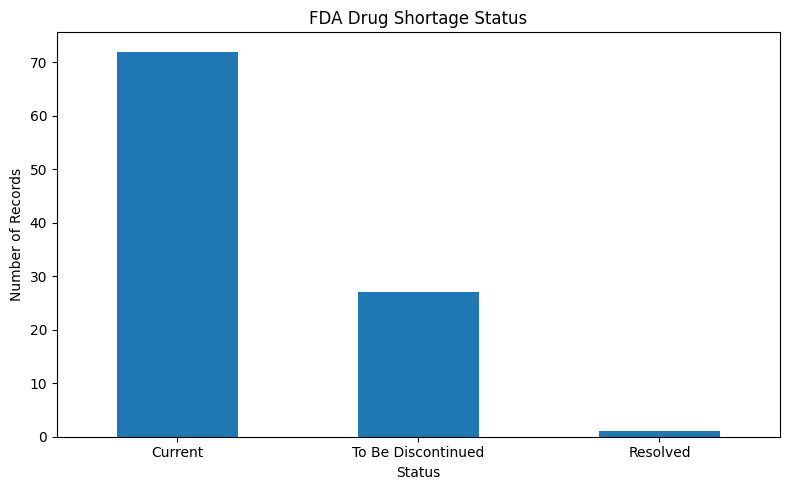

In [35]:
plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("FDA Drug Shortage Status")
plt.xlabel("Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [36]:
reason_counts = df["shortage_reason"].value_counts()

print("Top Drug Shortage Reasons:")
display(reason_counts.head(10))

Top Drug Shortage Reasons:


,count
shortage_reason,
Other,10
Demand increase for the drug,7
Discontinuation of the manufacture of the drug,2
Shortage of an active ingredient,1


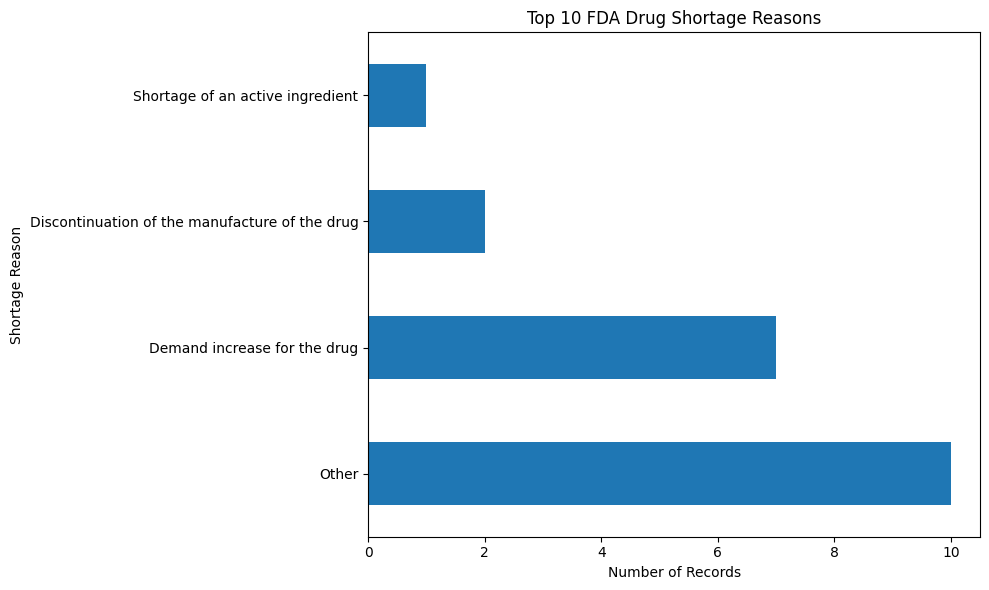

In [37]:
plt.figure(figsize=(10, 6))

reason_counts.head(10).plot(kind="barh")

plt.title("Top 10 FDA Drug Shortage Reasons")
plt.xlabel("Number of Records")
plt.ylabel("Shortage Reason")

plt.tight_layout()
plt.show()

In [38]:
category_counts = df["therapeutic_category"].value_counts()

print("Top Therapeutic Categories in FDA Drug Shortage Data:")
display(category_counts.head(10))

Top Therapeutic Categories in FDA Drug Shortage Data:


,count
therapeutic_category,
[Psychiatry],19
[Anesthesia],11
[Cardiovascular],8
[Analgesia/Addiction],7
[Anti-Infective],7
[Gastroenterology],6
[Neurology],4
"[Anesthesia, Neurology]",4
"[Anesthesia, Pediatric]",3


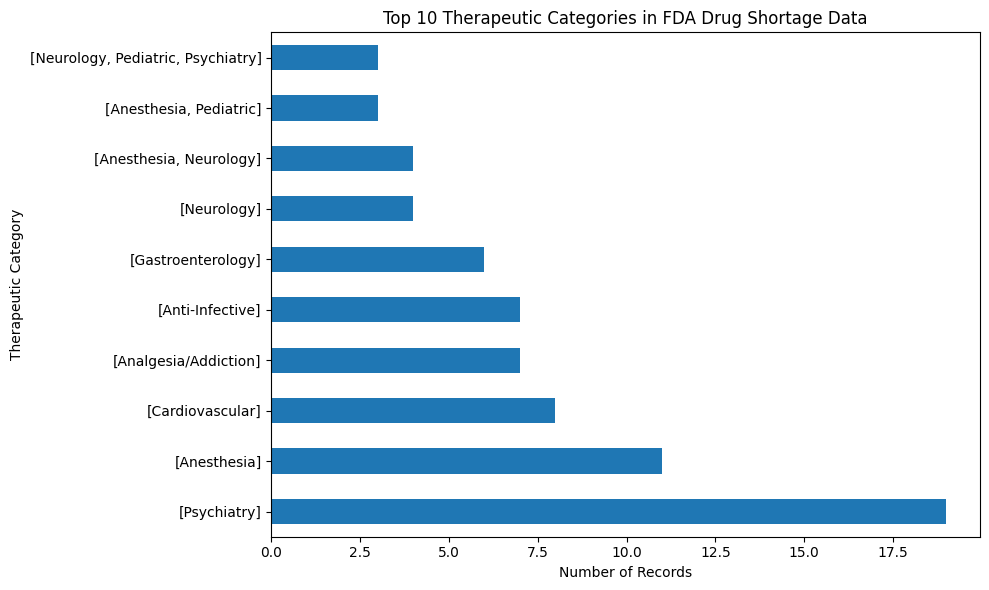

In [39]:
plt.figure(figsize=(10, 6))

category_counts.head(10).plot(kind="barh")

plt.title("Top 10 Therapeutic Categories in FDA Drug Shortage Data")
plt.xlabel("Number of Records")
plt.ylabel("Therapeutic Category")

plt.tight_layout()
plt.show()

In [40]:

company_counts = df["company_name"].value_counts()

print("Top Companies in FDA Drug Shortage Records:")
display(company_counts.head(10))

Top Companies in FDA Drug Shortage Records:


,count
company_name,
"Hospira, Inc., a Pfizer Company",9
"Hikma Pharmaceuticals USA, Inc.",7
"Fresenius Kabi USA, LLC",6
Pfizer Inc.,6
Sandoz Inc.,5
"Teva Pharmaceuticals USA, Inc.",5
"Sun Pharmaceutical Industries, Inc.",4
Baxter Healthcare,4
"Somerset Therapeutics, LLC",3


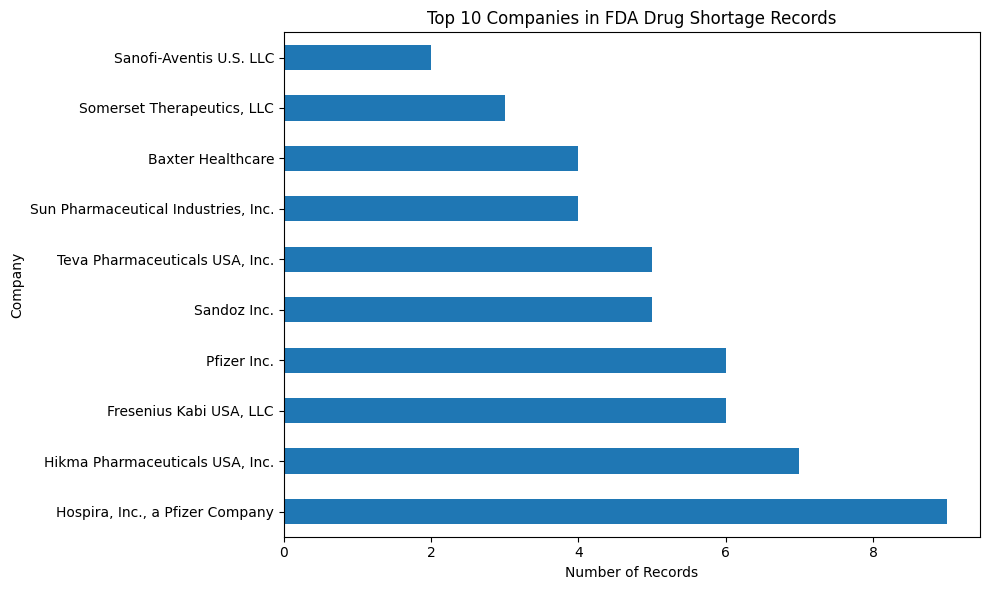

In [41]:
plt.figure(figsize=(10, 6))

company_counts.head(10).plot(kind="barh")

plt.title("Top 10 Companies in FDA Drug Shortage Records")
plt.xlabel("Number of Records")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

In [42]:
dosage_counts = df["dosage_form"].value_counts()

print("Top Dosage Forms in FDA Drug Shortage Records:")
display(dosage_counts.head(10))

Top Dosage Forms in FDA Drug Shortage Records:


,count
dosage_form,
Injection,56
Tablet,18
Capsule,12
"Tablet, Chewable",4
Solution,3
Oral Solution,1
"Capsule, Extended Release",1
Spray,1


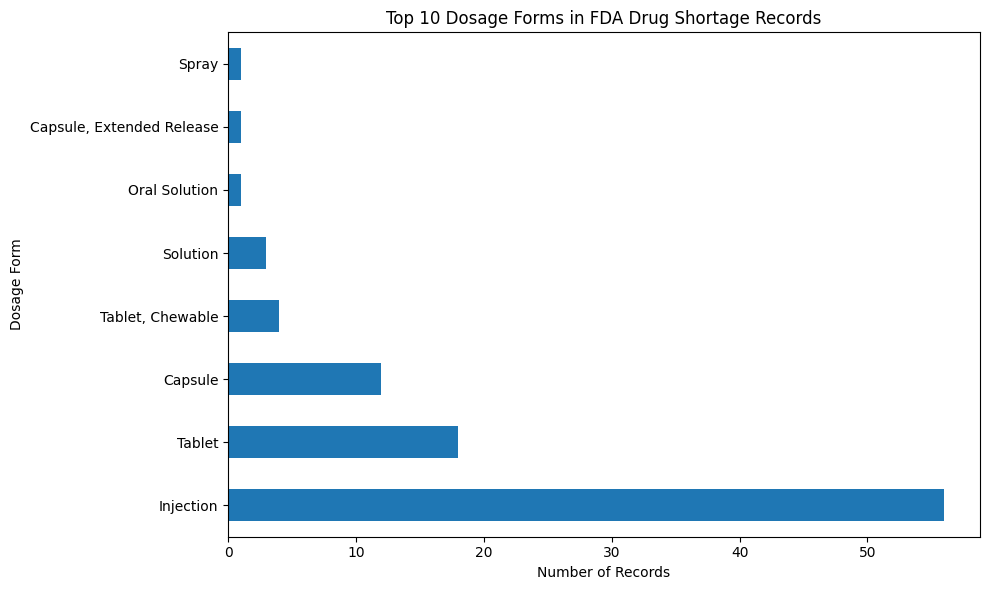

In [43]:
plt.figure(figsize=(10, 6))

dosage_counts.head(10).plot(kind="barh")

plt.title("Top 10 Dosage Forms in FDA Drug Shortage Records")
plt.xlabel("Number of Records")
plt.ylabel("Dosage Form")

plt.tight_layout()
plt.show()

In [44]:
missing_data = df.isnull().sum()

missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Fields with missing values:")
display(missing_data.head(15))

Fields with missing values:


,0
change_date,99
resolved_note,99
related_info_link,98
openfda.pharm_class_pe,98
openfda.pharm_class_moa,91
openfda.pharm_class_cs,88
shortage_reason,80
openfda.nui,77
openfda.pharm_class_epc,77
discontinued_date,73


In [45]:
print("FDA Drug Shortage Dataset Summary")
print("----------------------------------")
print("Total records:", len(df))
print("Unique generic drugs:", df["generic_name"].nunique())
print("Unique companies:", df["company_name"].nunique())

therapeutic_categories = df["therapeutic_category"].apply(
    lambda x: tuple(x) if isinstance(x, list) else x
).nunique()

print("Therapeutic categories:", therapeutic_categories)
print("Dosage forms:", df["dosage_form"].nunique())
print("Shortage reasons:", df["shortage_reason"].nunique())

FDA Drug Shortage Dataset Summary
----------------------------------
Total records: 100
Unique generic drugs: 58
Unique companies: 46
Therapeutic categories: 27
Dosage forms: 8
Shortage reasons: 4


In [46]:
clean_df = df[[
    "generic_name",
    "openfda.brand_name",
    "company_name",
    "status",
    "shortage_reason",
    "therapeutic_category",
    "dosage_form",
    "initial_posting_date",
    "update_date"
]].copy()

print("Clean dataset shape:", clean_df.shape)
display(clean_df.head())

Clean dataset shape: (100, 9)


,generic_name,openfda.brand_name,company_name,status,shortage_reason,therapeutic_category,dosage_form,initial_posting_date,update_date
0,Liraglutide Injection,[LIRAGLUTIDE],"Novo Nordisk, Inc.",Current,NaN,[Endocrinology/Metabolism],Injection,07/18/2023,09/22/2026
1,Clonazepam Tablet,[CLONAZEPAM],Aurobindo Pharma USA,Current,NaN,"[Neurology, Pediatric, Psychiatry]",Tablet,03/10/2023,06/02/2026
2,Hydromorphone Hydrochloride Injection,[HYDROMORPHONE HYDROCHLORIDE],"Hospira, Inc., a Pfizer Company",Current,NaN,[Analgesia/Addiction],Injection,10/31/2017,09/22/2026
3,Amino Acid Injection,NaN,Baxter Healthcare,Current,NaN,[Gastroenterology],Injection,12/08/2020,09/17/2026
4,Sodium Bicarbonate Injection,[SODIUM BICARBONATE],"Hospira, Inc., a Pfizer Company",To Be Discontinued,NaN,"[Endocrinology/Metabolism, Gastroenterology, P...",Injection,11/07/2025,11/07/2025


In [47]:
clean_df = df[[
    "generic_name",
    "openfda.brand_name",
    "company_name",
    "status",
    "shortage_reason",
    "therapeutic_category",
    "dosage_form",
    "initial_posting_date",
    "update_date"
]].copy()

print("Clean dataset shape:", clean_df.shape)
display(clean_df.head())

Clean dataset shape: (100, 9)


,generic_name,openfda.brand_name,company_name,status,shortage_reason,therapeutic_category,dosage_form,initial_posting_date,update_date
0,Liraglutide Injection,[LIRAGLUTIDE],"Novo Nordisk, Inc.",Current,NaN,[Endocrinology/Metabolism],Injection,07/18/2023,09/22/2026
1,Clonazepam Tablet,[CLONAZEPAM],Aurobindo Pharma USA,Current,NaN,"[Neurology, Pediatric, Psychiatry]",Tablet,03/10/2023,06/02/2026
2,Hydromorphone Hydrochloride Injection,[HYDROMORPHONE HYDROCHLORIDE],"Hospira, Inc., a Pfizer Company",Current,NaN,[Analgesia/Addiction],Injection,10/31/2017,09/22/2026
3,Amino Acid Injection,NaN,Baxter Healthcare,Current,NaN,[Gastroenterology],Injection,12/08/2020,09/17/2026
4,Sodium Bicarbonate Injection,[SODIUM BICARBONATE],"Hospira, Inc., a Pfizer Company",To Be Discontinued,NaN,"[Endocrinology/Metabolism, Gastroenterology, P...",Injection,11/07/2025,11/07/2025


In [48]:
print("KEY PROJECT FINDINGS")
print("--------------------")
print(f"FDA records analyzed: {len(df)}")
print(f"Unique generic drugs: {df['generic_name'].nunique()}")
print(f"Unique companies: {df['company_name'].nunique()}")

print("\nMost common shortage statuses:")
print(status_counts.head(3))

print("\nMost common shortage reasons:")
print(reason_counts.head(3))

print("\nMost common dosage forms:")
print(dosage_counts.head(3))

KEY PROJECT FINDINGS
--------------------
FDA records analyzed: 100
Unique generic drugs: 58
Unique companies: 46

Most common shortage statuses:
status
Current               72
To Be Discontinued    27
Resolved               1
Name: count, dtype: int64

Most common shortage reasons:
shortage_reason
Other                                             10
Demand increase for the drug                       7
Discontinuation of the manufacture of the drug     2
Name: count, dtype: int64

Most common dosage forms:
dosage_form
Injection    56
Tablet       18
Capsule      12
Name: count, dtype: int64


In [49]:
import os

print(os.listdir())

['.config', 'FDA_Drug_Shortage_Cleaned_Data.csv', 'sample_data']


In [50]:
clean_df.to_csv("FDA_Drug_Shortage_Cleaned_Data.csv", index=False)

print("CSV recreated successfully!")

CSV recreated successfully!


In [51]:
from google.colab import files

files.download("FDA_Drug_Shortage_Cleaned_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>